In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('advertising.csv')

# Первичный осмотр
print(df.info())
print(df.describe())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0


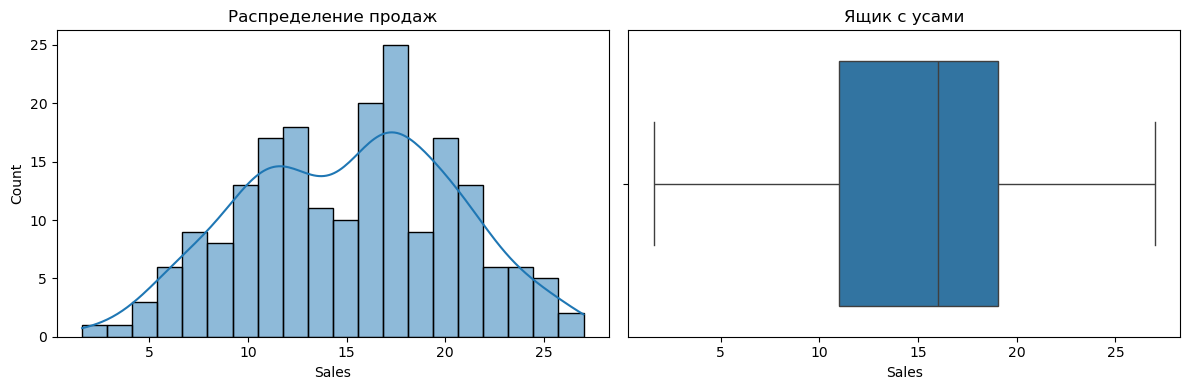

In [7]:
# Анализ целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Sales'], kde=True, bins=20, ax=axes[0])
axes[0].set_title('Распределение продаж')
sns.boxplot(x=df['Sales'], ax=axes[1])
axes[1].set_title('Ящик с усами')
plt.tight_layout()
plt.show()

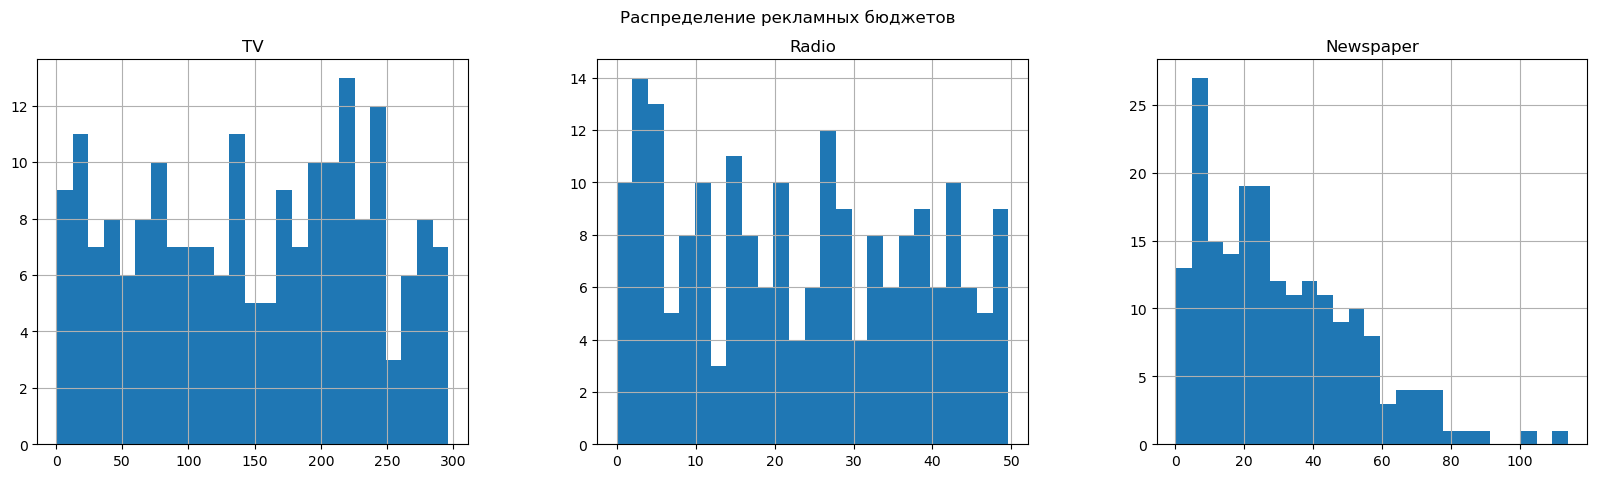

In [33]:
# Гистограммы признаков
df[['TV', 'Radio', 'Newspaper']].hist(bins=25, figsize=(20, 5), layout=(1,3))
plt.suptitle('Распределение рекламных бюджетов')
plt.show()

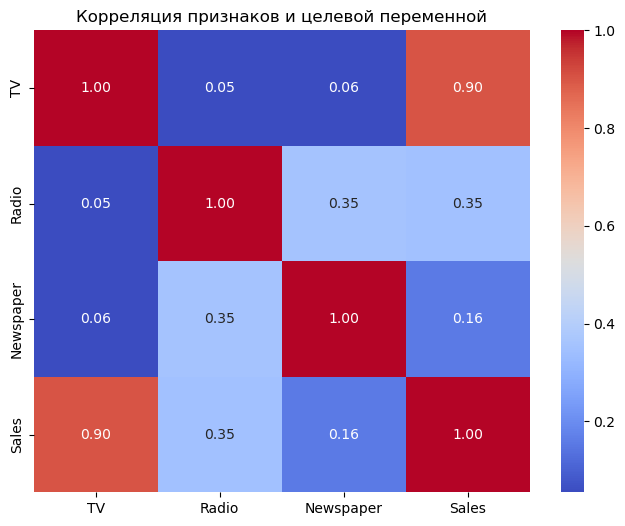

In [9]:
# Корреляционная матрица
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция признаков и целевой переменной')
plt.show()

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Проверка пропусков
print(df.isnull().sum())

# Разделение на признаки и целевую переменную
X = df.drop('Sales', axis=1)
y = df['Sales']

# Разделение на выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование (для линейных моделей)
'''
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
'''

# Масштабирование MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Немасштабированные копии для деревьев
X_train_tree = X_train.values
X_test_tree = X_test.values

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Линейная регрессия
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Дерево решений
dt = DecisionTreeRegressor(max_depth=4, random_state=42)
dt.fit(X_train_tree, y_train)

# Случайный лес
rf = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train_tree, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}: MAE={mae:.2f}, MSE={mse:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")

# Прогнозы
y_pred_lr = lr.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test_tree)
y_pred_rf = rf.predict(X_test_tree)

# Оценка
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")

Linear Regression: MAE=1.27, MSE=2.91, RMSE=1.71, R²=0.9059
Decision Tree: MAE=1.46, MSE=3.84, RMSE=1.96, R²=0.8756
Random Forest: MAE=0.94, MSE=1.49, RMSE=1.22, R²=0.9519



Важность признаков:
      Feature  Importance
0         TV    0.850067
1      Radio    0.133877
2  Newspaper    0.016056


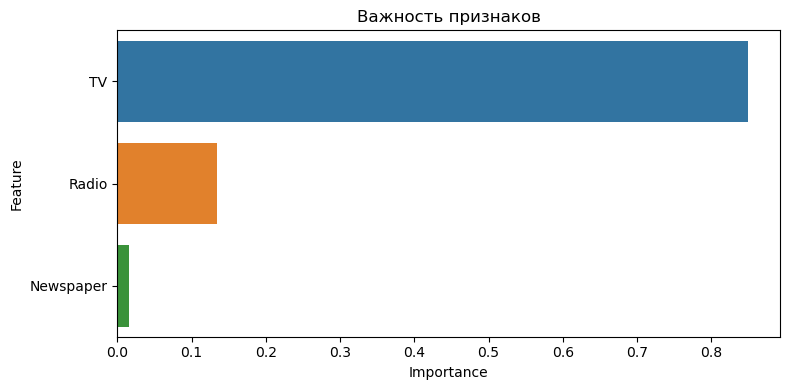

In [42]:
# Важность признаков для случайного леса
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nВажность признаков:\n", importances)

plt.figure(figsize=(8,4))
sns.barplot(data=importances, x='Importance', y='Feature', hue='Feature')
plt.title('Важность признаков')
plt.tight_layout()
plt.show()